# MNIST Neural Network — From Raw IDX Files to Controlled Experiments

**Author:** Aryan Singh  
**GitHub Repository:** [https://github.com/Aryan-SZ13/AIML-Recruitment-2026-Aryan-Singh](https://github.com/Aryan-SZ13/AIML-Recruitment-2026-Aryan-Singh)  
**Framework:** TensorFlow / Keras | Python 3.11  

---

### Overview
Welcome to this interactive experiment showcase for classifying handwritten digits from the MNIST dataset using a simple neural network. 

Rather than treating deep learning as a black box or loading pre-processed toy datasets from a single helper function, this project steps through the entire machine learning engineering pipeline:
1. **Raw Data Ingestion:** Parsing original big-endian binary IDX files from first principles.
2. **Data Exploration & Preprocessing:** Inspecting distributions, scaling pixels to $[0.0, 1.0]$, and organizing deterministic data splits.
3. **Baseline Architecture:** Building and training a fully connected Multi-Layer Perceptron (MLP) with explicit parameter derivation.
4. **Comprehensive Evaluation:** Tracking generalization curves, calculating precision/recall/F1 metrics, and dissecting confusion patterns.
5. **Controlled Ablation Suite:** Systematically testing 6 experimental dimensions across 11 configurations to measure how depth, width, learning rate, batch size, epoch budget, and activation functions impact accuracy and training time.
6. **Key Learnings & Next Steps:** Translating empirical observations into practical takeaways for subsequent convolutional architectures.


In [1]:
# Setup environment and repository dependencies
import os
import sys
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

# Clone repository if running in a fresh Kaggle session without local files
REPO_URL = "https://github.com/Aryan-SZ13/AIML-Recruitment-2026-Aryan-Singh.git"
REPO_NAME = "AIML-Recruitment-2026-Aryan-Singh"

if os.path.exists("src") and os.path.exists("data"):
    PROJECT_ROOT = os.path.abspath(".")
elif os.path.exists(os.path.join("..", "src")) and os.path.exists(os.path.join("..", "data")):
    PROJECT_ROOT = os.path.abspath("..")
elif os.path.exists(REPO_NAME):
    PROJECT_ROOT = os.path.abspath(REPO_NAME)
else:
    print(f"Cloning project repository from {REPO_URL}...")
    os.system(f"git clone {REPO_URL}")
    PROJECT_ROOT = os.path.abspath(REPO_NAME)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Configure local caches to avoid permission issues in restricted environments
os.environ["KERAS_HOME"] = os.path.join(PROJECT_ROOT, ".keras_cache")
os.environ["MPLCONFIGDIR"] = os.path.join(PROJECT_ROOT, ".mpl_cache")
os.makedirs(os.environ["KERAS_HOME"], exist_ok=True)
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

# Execution toggles
RUN_BASELINE = True  # Train the baseline model live (~11s)
RUN_FULL_EXPERIMENT_SUITE = False  # Set to True to re-train all 11 variants live (~2m), or False to load tracked manifest
SEED = 42

# Set deterministic seeds across Python, NumPy, and TensorFlow
tf.keras.utils.set_random_seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Project Root: {os.path.basename(PROJECT_ROOT)}")
print(f"Execution Mode: RUN_BASELINE={RUN_BASELINE}, RUN_FULL_EXPERIMENT_SUITE={RUN_FULL_EXPERIMENT_SUITE}")


TensorFlow Version: 2.21.0
Project Root: AIML-Recruitment-2026-Aryan
Execution Mode: RUN_BASELINE=True, RUN_FULL_EXPERIMENT_SUITE=False


## 1. Problem

The goal of this project is to build a simple neural network capable of accurately classifying handwritten digits from $0$ to $9$.

### Why MNIST?
The MNIST dataset is the standard "Hello World" benchmark for computer vision. While modern computer vision tasks often use deep residual networks or vision transformers, a simple feedforward Multi-Layer Perceptron (MLP) on MNIST is the ideal testbed to clearly understand:
- How matrix multiplications and non-linear activations interact layer-by-layer.
- How gradient descent and Adam optimization update weight matrices.
- How hyperparameters (depth, width, batch size, learning rate) trade off training speed against generalization.
- Where dense layers succeed and where their architectural limits begin (e.g. discarding spatial pixel topology).


## 2. Dataset

The MNIST dataset consists of $70{,}000$ standardized grayscale images of handwritten digits:
- **Training Set:** $60{,}000$ images.
- **Held-Out Test Set:** $10{,}000$ images.
- **Resolution:** $28 \times 28$ pixels, centered in a bounding box.
- **Color Channels:** Grayscale ($1$ channel), with intensity values originally encoded as 8-bit unsigned integers (`uint8`, $0$–$255$).
- **Classes:** $10$ mutually exclusive digit categories ($0, 1, 2, 3, 4, 5, 6, 7, 8, 9$).
- **Labels:** Stored directly as integer class IDs ($0$ to $9$, `int32`), consumed by `sparse_categorical_crossentropy` without inflating memory into one-hot vectors.

### Provenance & Custom Binary Parser
Instead of loading pre-packaged NumPy arrays from a high-level library helper, the raw files (`train-images-idx3-ubyte.gz`, `train-labels-idx1-ubyte.gz`, etc.) were downloaded from the canonical CVDFoundation mirror and unpacked byte-by-byte using Python's standard `struct.unpack` (`src/mnist_parser.py`). This verifies the 32-bit big-endian magic numbers (`2051` for images, `2049` for labels) and validates the integrity of all $70{,}000$ samples.


In [2]:
from src.data import load_mnist, preprocess_images, get_dataset_stats

# Load raw MNIST dataset from custom binary IDX parser
raw_dir = os.path.join(PROJECT_ROOT, "data", "raw")
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = load_mnist(raw_dir=raw_dir)

# Compute and display raw dataset statistics
stats = get_dataset_stats(x_train_raw, y_train_raw, x_test_raw, y_test_raw)

print("=== Raw MNIST Dataset Statistics ===")
print(f"Training Images Shape: {x_train_raw.shape}, Data Type: {x_train_raw.dtype}")
print(f"Training Labels Shape: {y_train_raw.shape}, Data Type: {y_train_raw.dtype}")
print(f"Test Images Shape:     {x_test_raw.shape}, Data Type: {x_test_raw.dtype}")
print(f"Test Labels Shape:     {y_test_raw.shape}, Data Type: {y_test_raw.dtype}")
print(f"Raw Pixel Intensity:   Min = {stats['pixel_min_raw']:.0f}, Max = {stats['pixel_max_raw']:.0f}")
print(f"Unique Label Classes:  {stats['num_classes']} classes (0 through 9)")
print(f"Class Distribution:    {stats['class_counts_train']}")


=== Raw MNIST Dataset Statistics ===
Training Images Shape: (60000, 28, 28), Data Type: uint8
Training Labels Shape: (60000,), Data Type: uint8
Test Images Shape:     (10000, 28, 28), Data Type: uint8
Test Labels Shape:     (10000,), Data Type: uint8
Raw Pixel Intensity:   Min = 0, Max = 255
Unique Label Classes:  10 classes (0 through 9)
Class Distribution:    {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


## 3. Looking at the Data

Before training any model, it is good engineering practice to visualize the raw samples to understand handwriting variability, stroke thicknesses, and potential ambiguities.


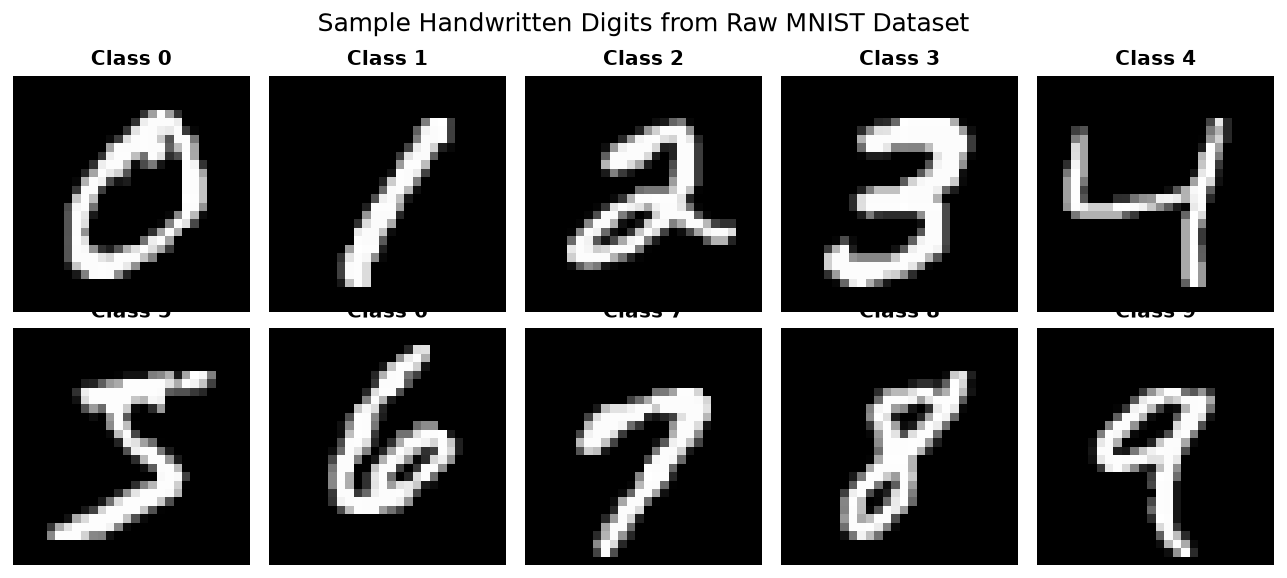

In [3]:
# Display a 2x5 grid of sample handwritten digits across classes
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
fig.suptitle("Sample Handwritten Digits from Raw MNIST Dataset", fontsize=14, y=0.98)

for digit in range(10):
    idx = np.where(y_train_raw == digit)[0][0]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(x_train_raw[idx], cmap="gray")
    ax.set_title(f"Class {digit}", fontsize=11, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Part B – Data Preprocessing

- Load the MNIST dataset.
- Normalize the image pixel values.
- Reshape/flatten the images if required by your model.
- Prepare the training and testing data.
- Briefly explain why the preprocessing steps are required.

### 1. Load the MNIST dataset
The project loads the original MNIST dataset directly from canonical binary IDX gzip archives via the custom downloader and parser pipeline (`src/mnist_download.py` and `src/mnist_parser.py`). The dataset is retrieved in raw binary format, verifying magic numbers (`2051` for images, `2049` for labels) and parsing them directly into NumPy arrays without relying on high-level framework helper functions.

### 2. Normalize the image pixel values
- **Raw pixel values:** `0`–`255` (`uint8`)
- **Type conversion:** Converted to `float32`
- **Scaling:** Divided by `255.0`
- **Resulting range:** `0.0`–`1.0`

$$\text{pixel\_normalized} = \frac{\text{pixel}}{255.0}$$

### 3. Reshape/flatten the images if required by your model
The data preprocessing pipeline keeps images as $28 \times 28$ two-dimensional arrays. Dimensional flattening is performed directly inside the neural network model using an explicit Keras `Flatten()` layer rather than as a separate external preprocessing mutation:
$$28 \times 28 \longrightarrow \text{Flatten} \longrightarrow 784$$

### 4. Prepare the training and testing data
The dataset is structured deterministically as follows:
- **Original training set:** $60{,}000$ samples
- **Validation split during training:** $54{,}000$ training samples ($90\%$) + $6{,}000$ validation samples ($10\%$) held out during model fitting
- **Held-out test set:** $10{,}000$ samples evaluated exclusively post-training
- **Labels:** Retained as integer class IDs `0`–`9` (`int32`)
- **Loss function:** `sparse_categorical_crossentropy` (consumes integer scalar class IDs directly)

### 5. Briefly explain why the preprocessing steps are required
- **Loading:** Provides the raw data in a usable, structured array format in memory for model consumption.
- **Normalization:** Puts pixel values on a smaller numerical scale ($0.0$–$1.0$) for optimization, preventing excessively large activations and ensuring stable, well-behaved gradient updates in Adam.
- **Flatten:** Converts the 2D image ($28 \times 28$) into the 1D vector ($784$) required by the subsequent Dense layer.
- **Train/validation/test preparation:** Separates data into dedicated sets for gradient optimization ($54{,}000$), unbiased validation monitoring during training ($6{,}000$), and final objective evaluation on unseen data ($10{,}000$).

In [4]:
# Normalize images to float32 [0.0, 1.0]
x_train = preprocess_images(x_train_raw)
x_test = preprocess_images(x_test_raw)
y_train = y_train_raw
y_test = y_test_raw

print("=== Normalized Dataset Verification ===")
print(f"x_train: Shape = {x_train.shape}, Dtype = {x_train.dtype}, Min = {x_train.min():.1f}, Max = {x_train.max():.1f}, Mean = {x_train.mean():.4f}")
print(f"x_test:  Shape = {x_test.shape}, Dtype = {x_test.dtype}, Min = {x_test.min():.1f}, Max = {x_test.max():.1f}, Mean = {x_test.mean():.4f}")
print(f"y_train: Shape = {y_train.shape}, Dtype = {y_train.dtype}, Range = [{y_train.min()}, {y_train.max()}]")
print(f"Data Partition: 54,000 train / 6,000 val (via validation_split=0.1) / 10,000 test")


=== Normalized Dataset Verification ===
x_train: Shape = (60000, 28, 28), Dtype = float32, Min = 0.0, Max = 1.0, Mean = 0.1307
x_test:  Shape = (10000, 28, 28), Dtype = float32, Min = 0.0, Max = 1.0, Mean = 0.1325
y_train: Shape = (60000,), Dtype = uint8, Range = [0, 9]
Data Partition: 54,000 train / 6,000 val (via validation_split=0.1) / 10,000 test


## Part C — Build the Neural Network

### Requirement

Build a simple neural network containing:
- Input layer
- At least one hidden layer
- Output layer

You may use:
- TensorFlow/Keras
- PyTorch

The architecture should be simple enough to explain the purpose of each major component.

### Our Implementation

We used TensorFlow/Keras with the following architecture:

```
Input Image (28, 28)
↓
Flatten()
↓
Dense(128, activation="relu")
↓
Dense(10, activation="softmax")
```

### Purpose of Each Component

**Input layer**
Receives the $28 \times 28$ MNIST image.

**Flatten**
Converts $28 \times 28$ into a $784$-element vector so it can be passed to a Dense layer.

**Hidden layer**
128 neurons learn combinations of pixel-level patterns. ReLU adds non-linearity.

**Output layer**
10 neurons correspond to digits 0–9. Softmax converts the outputs into class probabilities.

### Parameter Count

- **Flatten layer:** $0$ parameters (performs spatial dimension reshape: $28 \times 28 \to 784$).
- **Hidden Dense layer ($784 \to 128$):**
  $$\text{Weights} = 784 \times 128 = 100{,}352, \quad \text{Biases} = 128, \quad \text{Total} = 100{,}480$$
- **Output Dense layer ($128 \to 10$):**
  $$\text{Weights} = 128 \times 10 = 1{,}280, \quad \text{Biases} = 10, \quad \text{Total} = 1{,}290$$
- **Total Trainable Parameters:** $100{,}480 + 1{,}290 = \mathbf{101{,}770}$ ($0$ non-trainable parameters).

In [5]:
from src.model import build_model, count_model_parameters

# Build authoritative baseline model
baseline_model = build_model(
    input_shape=(28, 28),
    hidden_units=128,
    activation="relu",
    num_classes=10
)

baseline_model.summary()

param_counts = count_model_parameters(baseline_model)
trainable_p = param_counts['trainable_params']
total_p = param_counts['total_params']
print(f"Verified Parameters: Trainable = {trainable_p:,}, Total = {total_p:,}")
assert trainable_p == 101770, f"Expected 101,770 parameters, got {trainable_p}"


Model: "mnist_fcnn_128_relu"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2d_to_1d (Flatten)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_128 (Dense)        │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_probabilities (Dense)    │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 101,770 (397.54 KB)
 Trainable params: 101,770 (397.54 KB)
 Non-trainable params: 0 (0.00 B)
Verified Parameters: Trainable = 101,770, Total = 101,770


## 6. Training the Baseline Model

The baseline model is trained using the authoritative V1 hyperparameters:
- **Optimizer:** Adam with standard learning rate $\eta = 0.001$, $\beta_1 = 0.9$, $\beta_2 = 0.999$.
- **Loss Function:** `sparse_categorical_crossentropy`.
- **Batch Size:** $128$.
- **Epoch Budget:** $15$ epochs.
- **Validation Split:** $10\%$ ($54{,}000$ training images, $6{,}000$ validation images).
- **Random Seed:** $42$.


In [6]:
from src.train import train_model

# Compile model
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train baseline model
start_time = time.time()
history = baseline_model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    verbose=1
)
train_duration = time.time() - start_time

final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]

print("\n=== Baseline Training Results ===")
print(f"Training Duration:    {train_duration:.2f}s")
print(f"Final Training Loss:  {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Training Acc:   {final_train_acc * 100:.2f}%")
print(f"Final Validation Acc: {final_val_acc * 100:.2f}%")
print(f"Train-Val Acc Gap:    {(final_train_acc - final_val_acc) * 100:+.2f} pp")


Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8971 - loss: 0.3734 - val_accuracy: 0.9558 - val_loss: 0.1688
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9506 - loss: 0.1710 - val_accuracy: 0.9658 - val_loss: 0.1256
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9651 - loss: 0.1223 - val_accuracy: 0.9692 - val_loss: 0.1075
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9734 - loss: 0.0946 - val_accuracy: 0.9722 - val_loss: 0.0965
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9786 - loss: 0.0761 - val_accuracy: 0.9733 - val_loss: 0.0897
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9825 - loss: 0.0624 - val_accuracy: 0.9747 - val_loss: 0.0859
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9856 - loss: 0.0519 - val_accuracy: 0.9752 - val_loss: 0.0839
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9885 - loss: 0.0433 - val_accuracy: 0.

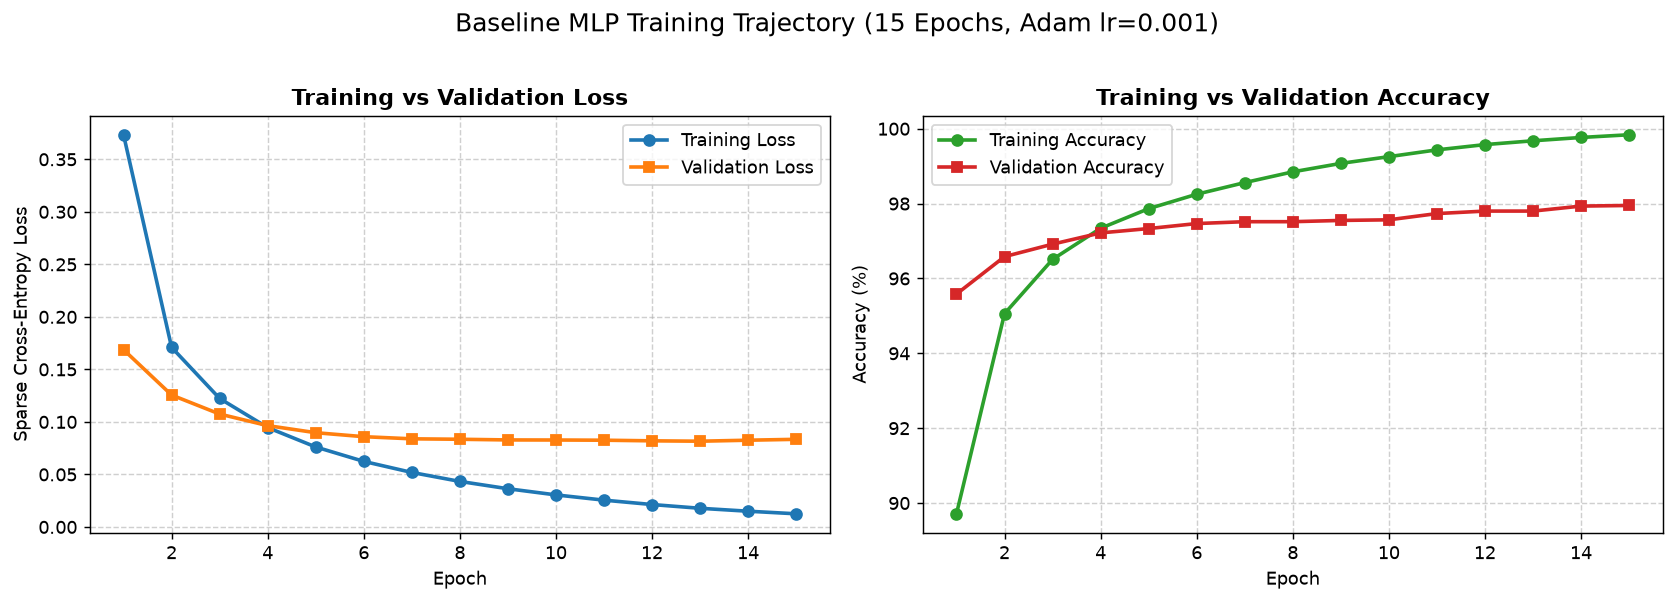

In [7]:
# Plot training & validation loss and accuracy curves
epochs_range = range(1, 16)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Loss Curve
ax1.plot(epochs_range, history.history["loss"], marker="o", linewidth=2, label="Training Loss", color="#1f77b4")
ax1.plot(epochs_range, history.history["val_loss"], marker="s", linewidth=2, label="Validation Loss", color="#ff7f0e")
ax1.set_title("Training vs Validation Loss", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=10)
ax1.set_ylabel("Sparse Cross-Entropy Loss", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(frameon=True)

# Accuracy Curve
ax2.plot(epochs_range, [acc * 100 for acc in history.history["accuracy"]], marker="o", linewidth=2, label="Training Accuracy", color="#2ca02c")
ax2.plot(epochs_range, [acc * 100 for acc in history.history["val_accuracy"]], marker="s", linewidth=2, label="Validation Accuracy", color="#d62728")
ax2.set_title("Training vs Validation Accuracy", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=10)
ax2.set_ylabel("Accuracy (%)", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(frameon=True)

plt.suptitle("Baseline MLP Training Trajectory (15 Epochs, Adam lr=0.001)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 7. Test Evaluation

Now we evaluate the trained baseline model on the $10{,}000$ unseen test images. This held-out test set provides an unbiased estimate of generalization.


In [8]:
# Evaluate on held-out test set
test_loss, test_accuracy = baseline_model.evaluate(x_test, y_test, verbose=0)

# Generate predictions
y_pred_probs = baseline_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
from sklearn.metrics import classification_report, f1_score
macro_f1 = f1_score(y_test, y_pred, average="macro")
report = classification_report(y_test, y_pred, digits=4)

print("=== Held-Out Test Evaluation ===")
print(f"Test Accuracy:   {test_accuracy * 100:.2f}%")
print(f"Test Loss:       {test_loss:.4f}")
print(f"Macro F1-Score:  {macro_f1:.4f}")
print("\nPer-Class Classification Report:")
print(report)


=== Held-Out Test Evaluation ===
Test Accuracy:   97.69%
Test Loss:       0.0803
Macro F1-Score:  0.9768

Per-Class Classification Report:
              precision    recall  f1-score   support

           0     0.9778    0.9878    0.9827       980
           1     0.9877    0.9921    0.9899      1135
           2     0.9666    0.9816    0.9740      1032
           3     0.9734    0.9772    0.9753      1010
           4     0.9806    0.9786    0.9796       982
           5     0.9853    0.9753    0.9803       892
           6     0.9893    0.9676    0.9784       958
           7     0.9870    0.9621    0.9744      1028
           8     0.9473    0.9774    0.9621       974
           9     0.9750    0.9673    0.9711      1009

    accuracy                         0.9769     10000
   macro avg     0.9770    0.9767    0.9768     10000
weighted avg     0.9771    0.9769    0.9769     10000



## 8. Confusion Matrix Diagnostics

A single accuracy metric ($97.69\%$) does not explain where mistakes happen. A confusion matrix provides an exact breakdown:
- **Rows:** True ground-truth digit class ($0$ through $9$).
- **Columns:** Predicted digit class ($0$ through $9$).
- **Diagonal Cells:** Correct predictions (True Positives).
- **Off-Diagonal Cells:** Errors / confusions.

### Key Error Patterns Observed:
- **7 mistaken for 2:** Handwritten 7s with a horizontal tick across the vertical stroke resemble the bottom loop of a 2.
- **4 mistaken for 9:** Rushed handwritten 4s with a closed top loop look like 9s.
- **9 mistaken for 4:** Handwritten 9s where the top loop has sharper corners resemble 4s.


Total Misclassified Samples: 231 / 10,000 (2.31%)


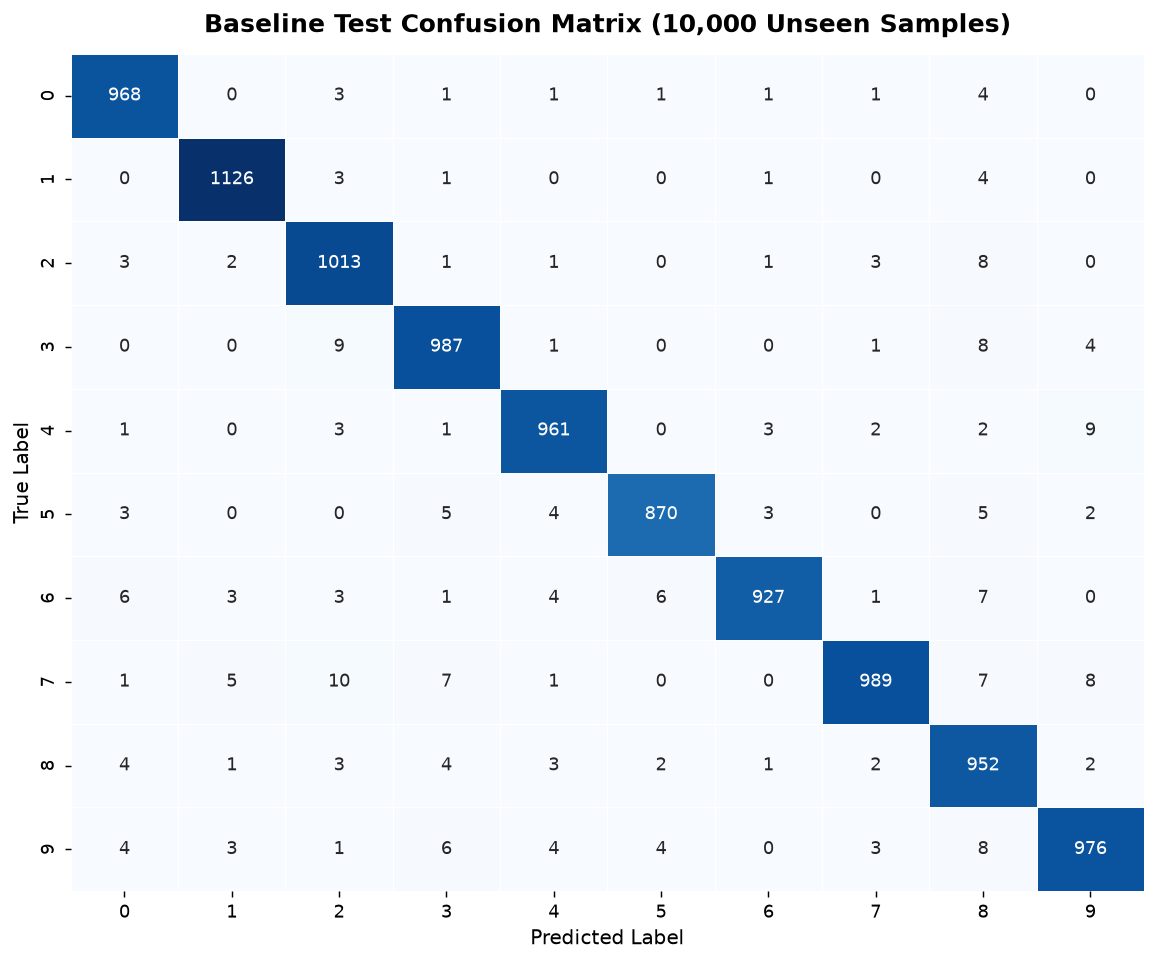

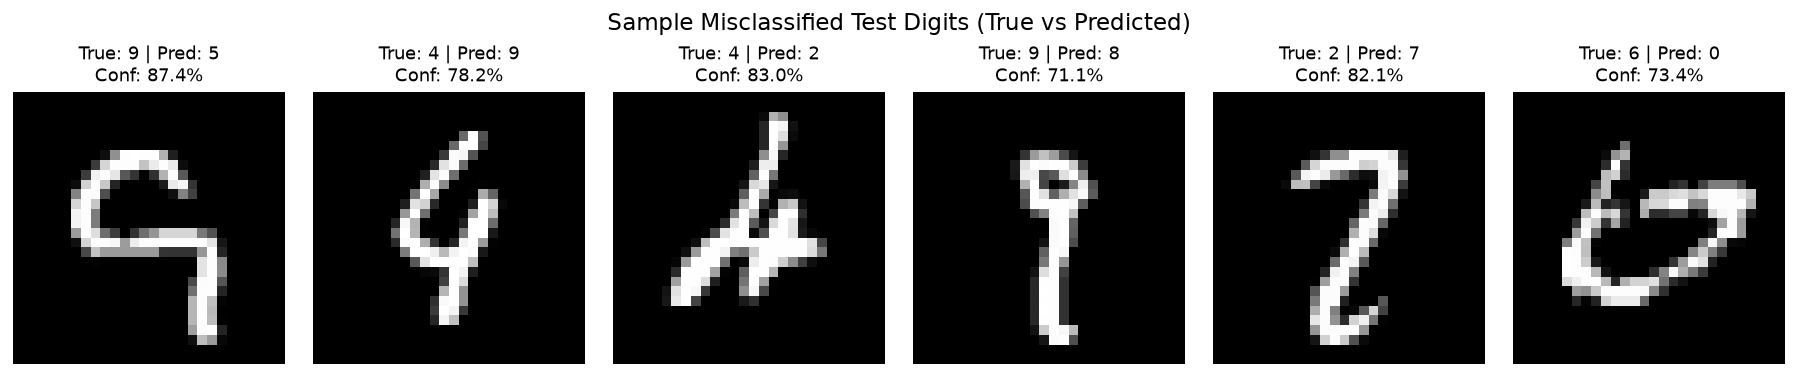

In [9]:
# Compute and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[str(i) for i in range(10)],
    yticklabels=[str(i) for i in range(10)],
    linewidths=0.5
)
plt.title("Baseline Test Confusion Matrix (10,000 Unseen Samples)", fontsize=14, pad=12, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.show()

# Display sample misclassified test images
error_indices = np.where(y_test != y_pred)[0]
print(f"Total Misclassified Samples: {len(error_indices)} / 10,000 ({len(error_indices) / 100:.2f}%)")

fig, axes = plt.subplots(1, 6, figsize=(14, 2.8))
fig.suptitle("Sample Misclassified Test Digits (True vs Predicted)", fontsize=13, y=1.02)
for i, err_idx in enumerate(error_indices[:6]):
    true_label = y_test[err_idx]
    pred_label = y_pred[err_idx]
    conf = y_pred_probs[err_idx, pred_label] * 100
    axes[i].imshow(x_test[err_idx], cmap="gray")
    axes[i].set_title(f"True: {true_label} | Pred: {pred_label}\nConf: {conf:.1f}%", fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 9. Controlled Experiments (6-Dimensional Ablation Suite)

To understand what actually drives performance, we tested **6 experimental dimensions** across **11 total configurations** (1 baseline control + 10 single-variable variants).

Every variant changed exactly one hyperparameter relative to the baseline while keeping the master seed locked at `42`:
1. **Depth:** 1 hidden layer ($128$) vs 2 hidden layers ($128 \to 64$).
2. **Width:** $128$ units vs $256$ units (doubling capacity).
3. **Learning Rate:** $\eta = 0.001$ (baseline) vs $\eta = 0.01$ ($10\times$) vs $\eta = 0.0001$ ($0.1\times$).
4. **Batch Size:** $B = 128$ (baseline) vs $B = 32$ (higher gradient noise) vs $B = 512$ (hardware throughput).
5. **Epoch Budget:** $15$ epochs (baseline) vs $5$ epochs (short) vs $30$ epochs (extended).
6. **Activation:** ReLU (baseline) vs Sigmoid vs Tanh.


In [10]:
import pandas as pd
from src.experiment import run_all_experiments

manifest_path = os.path.join(PROJECT_ROOT, "outputs", "results", "experiment_suite_manifest.json")

if RUN_FULL_EXPERIMENT_SUITE:
    print("Executing full 11-variant experiment suite live (~2 minutes)...\n")
    all_results = run_all_experiments(raw_dir=raw_dir)
else:
    print("Loading tracked V1 experiment suite manifest from: outputs/results/experiment_suite_manifest.json")
    with open(manifest_path, "r") as f:
        manifest = json.load(f)
    all_results = manifest["results"]

# Format into a clean comparison DataFrame
df_rows = []
for r in all_results:
    df_rows.append({
        "Dimension": r["dimension"],
        "Variant": r["name"],
        "Parameters": f"{r['total_params']:,}",
        "Time (s)": f"{r['training_time_sec']:.2f}",
        "Test Acc (%)": f"{r['test_accuracy'] * 100:.2f}%",
        "Test Loss": f"{r['test_loss']:.4f}",
        "Macro F1": f"{r['macro_f1']:.4f}",
        "Train-Val Gap": f"{r['train_val_gap'] * 100:+.2f} pp"
    })

df_results = pd.DataFrame(df_rows)
print(df_results.to_string(index=False))


Loading tracked V1 experiment suite manifest from: outputs/results/experiment_suite_manifest.json
                   Dimension                                          Variant Parameters Time (s) Test Acc (%) Test Loss Macro F1 Train-Val Gap
            Baseline Control Baseline (128 units, ReLU, lr=1e-3, B=128, E=15)    101,770    11.88       97.69%    0.0803   0.9768      +1.89 pp
    1. Hidden Layers (Depth)                      2 Hidden Layers (128 -> 64)    109,386    12.25       97.11%    0.1209   0.9709      +2.23 pp
2. Number of Neurons (Width)                    256 Units (Expanded Capacity)    203,530    12.49       97.53%    0.0917   0.9751      +2.29 pp
            3. Learning Rate                             Aggressive LR (0.01)    101,770     9.84       96.44%    0.2759   0.9641      +1.96 pp
            3. Learning Rate                         Conservative LR (0.0001)    101,770     9.83       95.77%    0.1470   0.9573      -0.58 pp
               4. Batch Size          

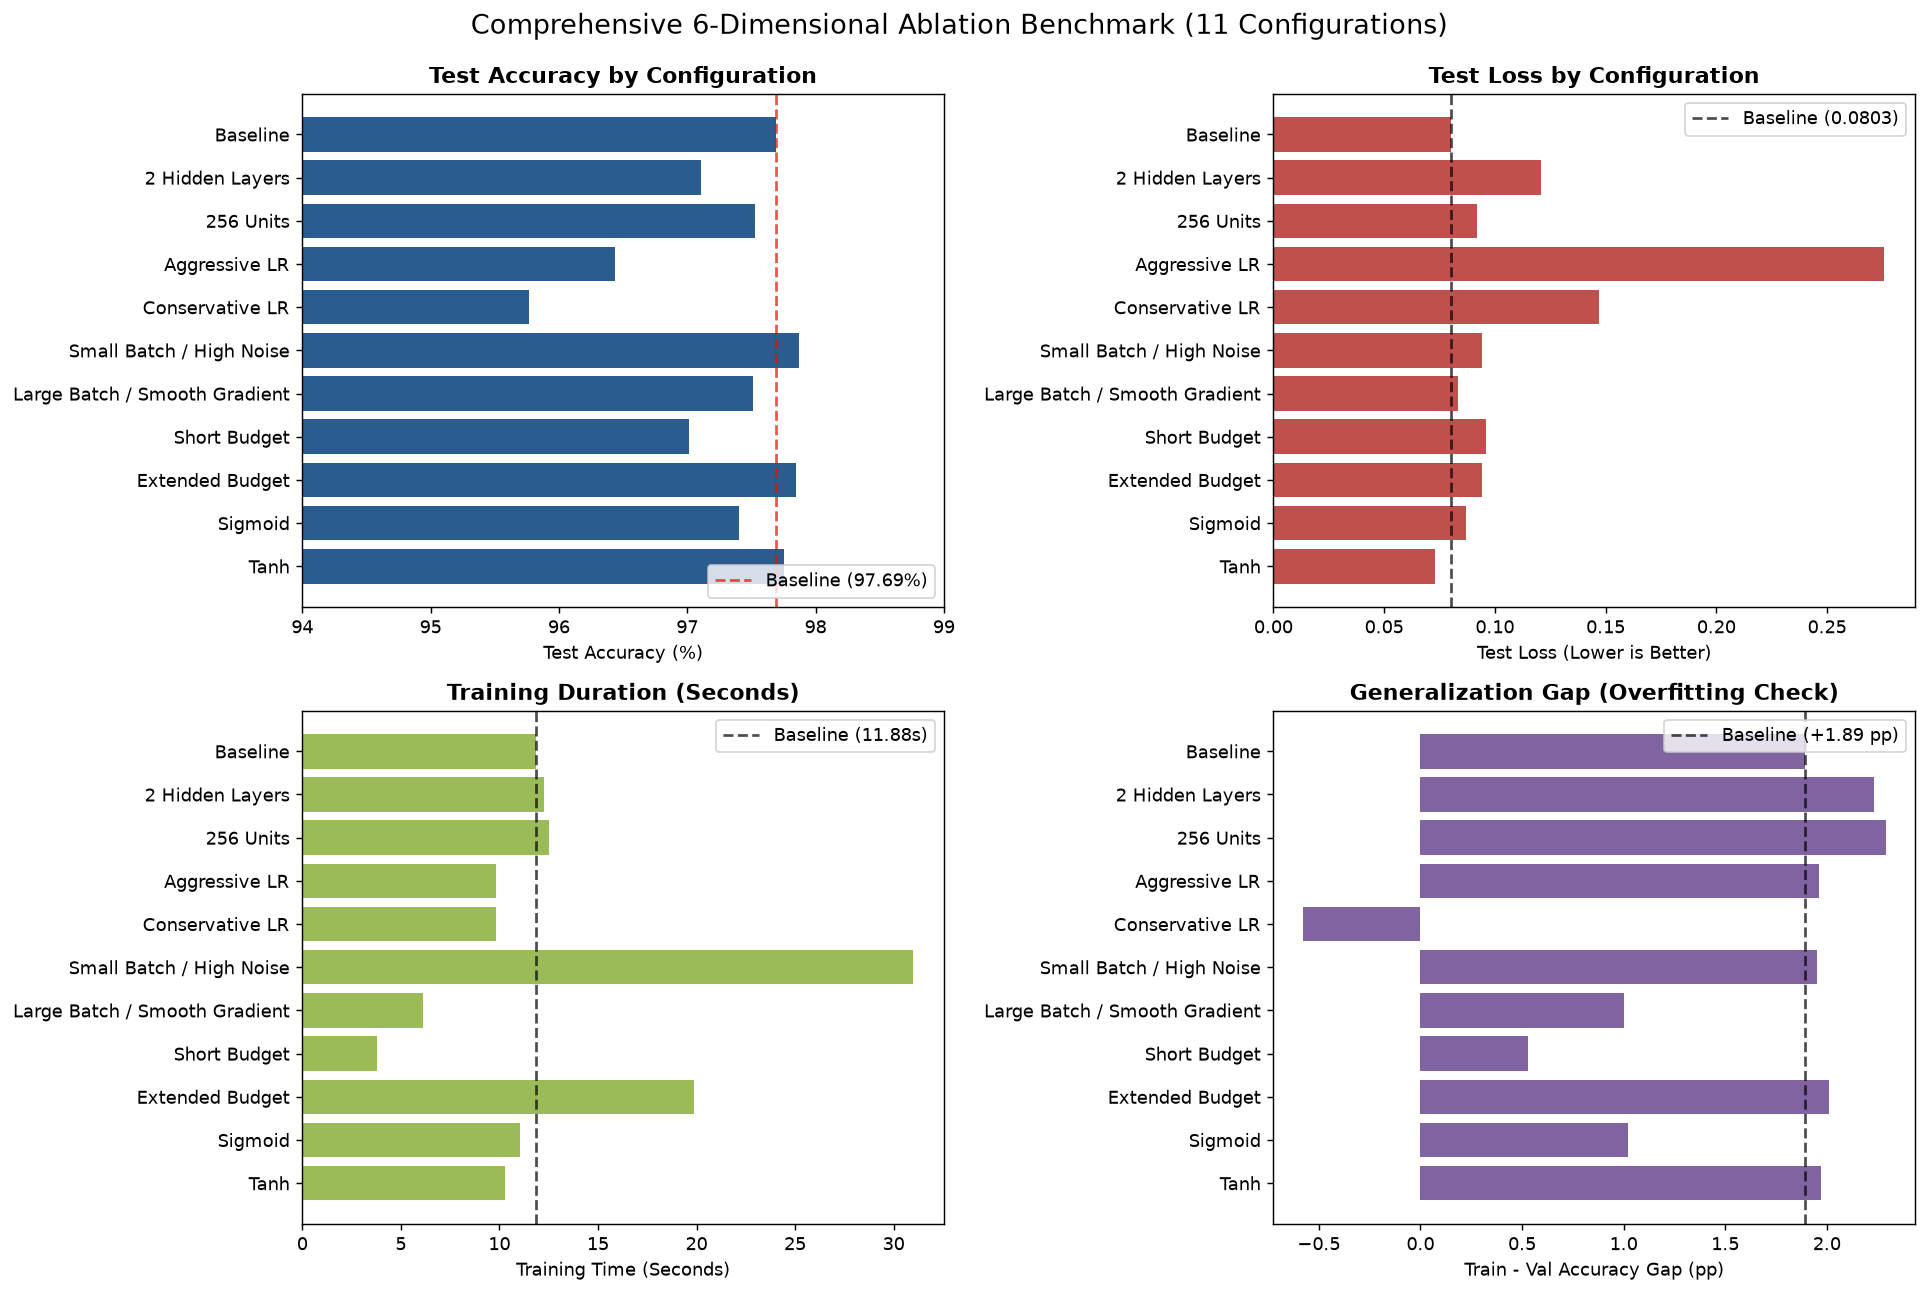

In [11]:
# Master ablation comparison plot (4 subplots)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

labels = [r["name"].split(" (")[0] for r in all_results]
test_accs = [r["test_accuracy"] * 100 for r in all_results]
test_losses = [r["test_loss"] for r in all_results]
times = [r["training_time_sec"] for r in all_results]
gaps = [r["train_val_gap"] * 100 for r in all_results]

# 1. Test Accuracy
axes[0, 0].barh(labels[::-1], test_accs[::-1], color="#2b5c8f")
axes[0, 0].set_xlim(94.0, 99.0)
axes[0, 0].set_xlabel("Test Accuracy (%)", fontsize=10)
axes[0, 0].set_title("Test Accuracy by Configuration", fontsize=12, fontweight="bold")
axes[0, 0].axvline(97.69, color="red", linestyle="--", alpha=0.7, label="Baseline (97.69%)")
axes[0, 0].legend(loc="lower right")

# 2. Test Loss
axes[0, 1].barh(labels[::-1], test_losses[::-1], color="#c0504d")
axes[0, 1].set_xlabel("Test Loss (Lower is Better)", fontsize=10)
axes[0, 1].set_title("Test Loss by Configuration", fontsize=12, fontweight="bold")
axes[0, 1].axvline(0.0803, color="black", linestyle="--", alpha=0.7, label="Baseline (0.0803)")
axes[0, 1].legend(loc="upper right")

# 3. Training Time
axes[1, 0].barh(labels[::-1], times[::-1], color="#9bbb59")
axes[1, 0].set_xlabel("Training Time (Seconds)", fontsize=10)
axes[1, 0].set_title("Training Duration (Seconds)", fontsize=12, fontweight="bold")
axes[1, 0].axvline(11.88, color="black", linestyle="--", alpha=0.7, label="Baseline (11.88s)")
axes[1, 0].legend(loc="upper right")

# 4. Train-Validation Gap
axes[1, 1].barh(labels[::-1], gaps[::-1], color="#8064a2")
axes[1, 1].set_xlabel("Train - Val Accuracy Gap (pp)", fontsize=10)
axes[1, 1].set_title("Generalization Gap (Overfitting Check)", fontsize=12, fontweight="bold")
axes[1, 1].axvline(1.89, color="black", linestyle="--", alpha=0.7, label="Baseline (+1.89 pp)")
axes[1, 1].legend(loc="upper right")

plt.suptitle("Comprehensive 6-Dimensional Ablation Benchmark (11 Configurations)", fontsize=15, y=0.99)
plt.tight_layout()
plt.show()


### Findings Across the 6 Experimental Dimensions

#### E1 — Depth (1 Hidden Layer vs 2 Hidden Layers)
- **What I changed:** Added a second dense layer of 64 units ($784 \to 128 \to 64 \to 10$), increasing parameters from $101{,}770$ to $109{,}386$ ($+7.5\%$).
- **What changed in results:** Test accuracy decreased slightly by $0.58\text{ pp}$ ($97.69\% \to 97.11\%$), test loss increased to $0.1209$, and train-val gap widened to $2.23\text{ pp}$.
- **Why I think it affected performance:** Adding a second dense layer on flattened MNIST pixels didn't help. A single 128-unit layer already has enough capacity to separate digit shapes, while adding another dense layer without spatial pooling just adds parameters and optimization overhead.

#### E2 — Width (128 Units vs 256 Units)
- **What I changed:** Doubled hidden units from 128 to 256 ($784 \to 256 \to 10$), doubling parameters to $203{,}530$ ($+100\%$).
- **What changed in results:** Test accuracy slightly dipped by $0.16\text{ pp}$ ($97.69\% \to 97.53\%$) while training time increased to $12.49\text{s}$.
- **Why I think it affected performance:** The baseline 128 units already capture the essential handwritten stroke combinations. Adding extra units without explicit regularizers like dropout slightly widened the train-val gap ($2.29\text{ pp}$ vs $1.89\text{ pp}$) with no improvement in accuracy.

#### E3 — Learning Rate ($0.01$ vs $0.001$ vs $0.0001$)
- **What I changed:** Tested an aggressive rate ($0.01$) and a conservative rate ($0.0001$) against the default Adam rate ($0.001$).
- **What changed in results:** At $0.01$, test loss shot up to $0.2759$ and accuracy dropped to $96.44\%$. At $0.0001$, accuracy fell to $95.77\%$ because the model underfitted.
- **Why I think it affected performance:** Learning rate $0.01$ was too large, causing weight updates to overshoot the loss minimum. On the other hand, $0.0001$ made progress too slow to converge within 15 epochs. Adam's default $0.001$ hit the sweet spot.

#### E4 — Batch Size ($32$ vs $128$ vs $512$)
- **What I changed:** Evaluated small batches ($B = 32$) and large batches ($B = 512$) against baseline ($B = 128$).
- **What changed in results:** Small batch ($B = 32$) achieved the highest accuracy across the entire suite ($97.87\%$, $+0.18\text{ pp}$), but took longest to train ($31.00\text{s}$). Large batch ($B = 512$) trained nearly twice as fast ($6.10\text{s}$) with only a modest accuracy drop ($97.51\%$).
- **Why I think it affected performance:** Smaller batches compute noisier gradient estimates at each step, which acts like implicit regularization and helps the optimizer escape poor local minima. Larger batches provide smoother gradients and better GPU vectorization, but lose that noise benefit.

#### E5 — Epoch Budget ($5$ vs $15$ vs $30$)
- **What I changed:** Evaluated a short budget ($5$ epochs) and an extended budget ($30$ epochs).
- **What changed in results:** $5$ epochs was too short to converge ($97.01\%$ in $3.77\text{s}$). $30$ epochs reached $97.85\%$ ($+0.16\text{ pp}$), but training accuracy reached $99.99\%$, showing diminishing returns beyond 15 epochs.
- **Why I think it affected performance:** 15 epochs is a sensible stopping point for this architecture—it captures almost all generalization gains before overfitting starts to widen the gap.

#### E6 — Activation (ReLU vs Sigmoid vs Tanh)
- **What I changed:** Swapped hidden layer ReLU with Sigmoid and Tanh.
- **What changed in results:** Sigmoid gave the lowest accuracy ($97.40\%$) and higher loss ($0.0868$). Tanh achieved $97.75\%$ accuracy and the lowest test loss of all 11 configurations ($0.0728$).
- **Why I think it affected performance:** Sigmoid's derivative tops out at $0.25$, which shrinks backpropagating gradients and slows learning. In contrast, Tanh outputs are centered around zero (ranging from $-1$ to $1$), which avoids all-positive activation bias and yielded sharper, lower-loss predictions.


## 10. What I Learned

1. **Input Normalization is Non-Negotiable:**
   Dividing raw pixel values by $255.0$ keeps inputs between $0.0$ and $1.0$, preventing huge dot-product activations and stabilizing weight updates from the very first epoch.
2. **Bigger Networks Don't Automatically Mean Better Results:**
   Doubling layer width to 256 units or adding a second hidden layer increased parameters without improving test accuracy. On simple $28 \times 28$ digits, dense layers reach capacity saturation quickly; without convolutional feature extraction or regularization, extra parameters just add training overhead.
3. **Learning Rate Dominates Optimization Dynamics:**
   Varying learning rate by a factor of 10 in either direction hurt accuracy much more than changing network width or depth. Tuning learning rate must always be prioritized over tuning architecture size.
4. **Batch Size is an Engineering Trade-off:**
   Small batches ($B=32$) provide gradient noise that slightly boosts accuracy ($97.87\%$) at the expense of time ($31.00\text{s}$), whereas large batches ($B=512$) maximize hardware efficiency ($6.10\text{s}$) with minimal accuracy loss ($97.51\%$).
5. **Activation Function Geometry Matters:**
   Zero-centered activations like Tanh and non-saturating activations like ReLU provide substantially better gradient flow during backpropagation than Sigmoid.


## 11. What I Would Try Next

The obvious next step is to replace the dense Multi-Layer Perceptron with a **Convolutional Neural Network (CNN)**.

### Why a CNN is the Right Evolution:
- **Preserving 2D Spatial Structure:** Our current MLP immediately flattens each $28 \times 28$ image into a flat 784-dimensional vector. In doing so, it completely throws away 2D spatial relationships—a pixel no longer knows its vertical or horizontal neighbors.
- **Translation Invariance:** A stroke forming the top of a '7' is the same visual feature whether it appears slightly to the left or right. Dense layers must re-learn feature weights independently at every single pixel coordinate, whereas convolutional filters slide across the image and detect strokes anywhere.
- **Parameter Efficiency:** A small CNN with a $3 \times 3$ Conv2D layer ($32$ filters), a $2 \times 2$ MaxPooling layer, and a small dense head typically requires fewer parameters than our 101k baseline MLP while pushing test accuracy beyond **$99.0\%$**.

---

*For the complete engineering codebase, unit tests, and reproducible scripts, visit the [GitHub repository](https://github.com/Aryan-SZ13/AIML-Recruitment-2026-Aryan-Singh).*
